# Pembuatan Dataset untuk Model 3 (Anomaly Detector)

Dataset untuk model 3 dibuat synthetic sepenuhnya karena tidak ada dataset publik yang memiliki fitur sensor bus (speed, engine_temp, passenger_count) secara bersamaan dengan label anomali ground truth.

In [9]:
import pandas as pd
import numpy as np
import random
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

NUM_BUSES = 30 
NUM_DAYS = 30
OP_START = 5 
OP_END = 22
INTERVAL_MINUTES = 0.5 
CONTAMINATION = 0.05

Ditetapkan banyak bus (NUM_BUSES) sebanyak 30 sesuai PRD yang diasumsikan setiap bus hanya melayani satu rute sehingga hanya terdapat 30 rute. Lama pemantauan selama 30 hari (1 bulan) dan setiap harinya dipantau selama jam operasional (05.00-22.00) dengan interval selama 30 detik untuk setiap barisnya. Dataset dirancang dengan contamination rate sebesar 5%, di mana anomali di-inject secara event-based dengan durasi bervariasi per tipe  

In [10]:
# --- 1. Pemetaan Bus ke Rute (Fixed 1-to-1) ---
bus_route_mapping = {f"BUS_{i:02d}": f"ROUTE_{i:02d}" for i in range(1, NUM_BUSES + 1)}

# --- 2. Generate Base Timestamps (Per 30 Detik) ---
start_time = datetime.strptime(f"{OP_START}:00", "%H:%M")
end_time = datetime.strptime(f"{OP_END}:00", "%H:%M")
delta = timedelta(minutes=INTERVAL_MINUTES)

timestamps_one_day = []
current_time = start_time
while current_time < end_time:
    timestamps_one_day.append(current_time.time())
    current_time += delta

# --- 3. Simulasikan Data Awal (Normal) ---
data_list = []
for bus_id_num in range(1, NUM_BUSES + 1):
    bus_id = f"BUS_{bus_id_num:02d}"
    route_id = bus_route_mapping[bus_id]
    
    for day in range(1, NUM_DAYS + 1):
        for ts in timestamps_one_day:
            hour = ts.hour
            is_peak = (7 <= hour < 9) or (16 <= hour < 18)
            
            if is_peak:
                speed = np.random.normal(loc=15, scale=3)
                passenger = np.random.normal(loc=58, scale=6)
                base_temp = 92
            else:
                speed = np.random.normal(loc=38, scale=5)
                passenger = np.random.normal(loc=18, scale=4)
                base_temp = 85
                
            speed = np.clip(speed, 0, 60)
            passenger = np.clip(passenger, 0, 80)
            engine_temp = np.clip(np.random.normal(loc=base_temp, scale=3), 70, 105)
            
            data_list.append({
                "bus_id": bus_id,
                "route_id": route_id,
                "day": day,
                "timestamp": ts.strftime("%H:%M:%S"),
                "hour": hour,
                "speed_kmh": round(speed, 2),
                "passenger_count": int(passenger),
                "engine_temp_c": round(engine_temp, 1)
            })

df = pd.DataFrame(data_list)
print(df.head(5))

   bus_id  route_id  day timestamp  hour  speed_kmh  passenger_count  \
0  BUS_01  ROUTE_01    1  05:00:00     5      41.45               15   
1  BUS_01  ROUTE_01    1  05:00:30     5      42.70               19   
2  BUS_01  ROUTE_01    1  05:01:00     5      36.79               20   
3  BUS_01  ROUTE_01    1  05:01:30     5      44.12               13   
4  BUS_01  ROUTE_01    1  05:02:00     5      37.13               14   

   engine_temp_c  
0           83.0  
1           85.9  
2           84.7  
3           84.7  
4           89.7  


Kerangka dasar dataset dibuat dengan memetakan 30 bus ke 30 rute secara fixed (satu bus satu rute). Timestamp dibentuk dari jam operasional 05:00–21:59:30 dengan interval 30 detik per baris. Nilai speed_kmh, passenger_count, dan engine_temp_c dibuat menggunakan distribusi normal (np.random.normal) dengan parameter loc dan scale yang berbeda antara jam sibuk (07:00–09:00 dan 16:00–18:00) dan jam normal, kemudian di-clip ke rentang masing-masing sebagai guardrail: speed 0–60 km/h, passenger 0–80 orang, engine_temp 70–105°C.

In [11]:
# 1. Pastikan urutan benar berbasis kronologis per bus
df = df.sort_values(by=["bus_id", "day", "timestamp"]).reset_index(drop=True)

# 2. Definisikan Groupby objek berdasarkan bus_id
# Menggunakan 120 observasi karena 120 baris x 30 detik = 3600 detik (1 jam)
grouped_bus = df.groupby("bus_id")["speed_kmh"]

# 3. Hitung Rolling Mean dan Rolling Std
df["rolling_mean_1h"] = grouped_bus.rolling(window=120, min_periods=1).mean().reset_index(level=0, drop=True)
df["rolling_std_1h"] = grouped_bus.rolling(window=120, min_periods=2).std().reset_index(level=0, drop=True)

# 4. Hitung Z-Score & Handle NaN (NaN muncul pada baris pertama per grup karena std butuh min_periods=2)
df["z_score"] = (df["speed_kmh"] - df["rolling_mean_1h"]) / df["rolling_std_1h"]
df["z_score"] = df["z_score"].fillna(0)

# Memastikan hasil round agar data rapi
df["rolling_mean_1h"] = df["rolling_mean_1h"].round(2)
df["rolling_std_1h"] = df["rolling_std_1h"].round(2)
df["z_score"] = df["z_score"].round(4)

Sebelum menghitung derived features, dataset diurutkan kronologis per bus agar urutan time series benar. Kemudian dihitung rolling mean kecepatan dalam window 1 jam terakhir (120 observasi × 30 detik) per bus yang ini menjadi rolling_mean_1h. Z-score lalu dihitung untuk mengukur seberapa jauh kecepatan saat ini menyimpang dari rata-rata 1 jam terakhir bus tersebut. Baris pertama per bus yang tidak memiliki cukup data historis di-fill dengan 0.

In [13]:
print(f"Total rows: {len(df):,}")
print("\nSampel data setelah Step 3 (Melihat indeks awal jendela rolling):")
print(df[["bus_id", "day", "timestamp", "speed_kmh", "rolling_mean_1h", "z_score"]].head(5))

Total rows: 1,836,000

Sampel data setelah Step 3 (Melihat indeks awal jendela rolling):
   bus_id  day timestamp  speed_kmh  rolling_mean_1h  z_score
0  BUS_01    1  05:00:00      41.45            41.45   0.0000
1  BUS_01    1  05:00:30      42.70            42.08   0.7071
2  BUS_01    1  05:01:00      36.79            40.31  -1.1312
3  BUS_01    1  05:01:30      44.12            41.26   0.8988
4  BUS_01    1  05:02:00      37.13            40.44  -0.9980


In [14]:
ANOMALY_CONFIG = {
    'overspeed':           {'duration_range': (5, 15),  'severity': 'High'},
    'mogok':               {'duration_range': (20, 60), 'severity': 'High'},
    'overheat':            {'duration_range': (10, 30), 'severity': 'High'},
    'overloaded':          {'duration_range': (5, 20),  'severity': 'Medium'},
    'sensor_malfunction':  {'duration_range': (3, 10),  'severity': 'Medium'},
    'kecelakaan':          {'duration_range': (3, 8),   'severity': 'High'},
}

TOTAL_ROWS = len(df)
TARGET_ANOMALY_ROWS = int(TOTAL_ROWS * CONTAMINATION)

df['is_anomaly'] = 0
df['anomaly_type'] = 'Normal'

anomaly_mask = np.zeros(TOTAL_ROWS, dtype=bool)
current_anomaly_rows = 0
anomaly_types = list(ANOMALY_CONFIG.keys())

while current_anomaly_rows < TARGET_ANOMALY_ROWS:
    atype = np.random.choice(anomaly_types)
    drange = ANOMALY_CONFIG[atype]['duration_range']
    duration = np.random.randint(drange[0], drange[1] + 1)
    
    start_idx = np.random.randint(0, TOTAL_ROWS - duration)
    end_idx = start_idx + duration
    
    # Proteksi Overlap
    if np.any(anomaly_mask[start_idx:end_idx]):
        continue
        
    # Proteksi Batas Bus
    if df.loc[start_idx, 'bus_id'] != df.loc[end_idx - 1, 'bus_id']:
        continue
        
    anomaly_range = range(start_idx, end_idx)
    
    # Eksekusi Signature Anomali
    if atype == 'overspeed':
        df.loc[anomaly_range, 'speed_kmh'] = np.round(np.random.normal(72, 4, size=duration), 2)
        
    elif atype == 'mogok':
        df.loc[anomaly_range, 'speed_kmh'] = 0.0
        df.loc[anomaly_range, 'engine_temp_c'] = np.round(np.random.normal(40, 2, size=duration), 1)
        
    elif atype == 'overheat':
        df.loc[anomaly_range, 'engine_temp_c'] = np.round(np.random.normal(115, 3, size=duration), 1)
        df.loc[anomaly_range, 'speed_kmh'] = np.round(np.random.normal(15, 2, size=duration), 2)
        
    elif atype == 'overloaded':
        df.loc[anomaly_range, 'passenger_count'] = np.random.randint(85, 110, size=duration)
        df.loc[anomaly_range, 'speed_kmh'] = np.round(df.loc[anomaly_range, 'speed_kmh'] * 0.7, 2)
        
    elif atype == 'sensor_malfunction':
        df.loc[anomaly_range, 'speed_kmh'] = np.round(np.random.uniform(150, 300, size=duration), 2)
        df.loc[anomaly_range, 'engine_temp_c'] = np.round(np.random.uniform(-10, 0, size=duration), 1)
        
    elif atype == 'kecelakaan':
        df.loc[anomaly_range, 'speed_kmh'] = 0.0
        df.loc[anomaly_range, 'engine_temp_c'] = np.round(np.random.normal(118, 4, size=duration), 1)
        
    # Update Metadata Tracker
    df.loc[anomaly_range, 'is_anomaly'] = 1
    df.loc[anomaly_range, 'anomaly_type'] = atype
    anomaly_mask[start_idx:end_idx] = True
    
    current_anomaly_rows += duration

# Final Guardrail Clipping khusus data non-malfunction
clean_mask = df['anomaly_type'].isin(['Normal', 'overspeed', 'mogok', 'overheat', 'overloaded', 'kecelakaan'])
df.loc[clean_mask, 'speed_kmh'] = df.loc[clean_mask, 'speed_kmh'].clip(0, 90)

In [15]:
actual_percentage = (df['is_anomaly'].sum() / TOTAL_ROWS) * 100
print(f"Total Baris Dataset      : {len(df):,}")
print(f"Total Baris Anomali      : {df['is_anomaly'].sum():,}")
print(f"Persentase Kontaminasi   : {actual_percentage:.2f}% (Target: {CONTAMINATION*100}%)")
print("\nKeseimbangan Tipe Anomali:")
print(df['anomaly_type'].value_counts())

Total Baris Dataset      : 1,836,000
Total Baris Anomali      : 91,804
Persentase Kontaminasi   : 5.00% (Target: 5.0%)

Keseimbangan Tipe Anomali:
anomaly_type
Normal                1744196
mogok                   38292
overheat                19577
overloaded              11848
overspeed                9986
sensor_malfunction       6505
kecelakaan               5596
Name: count, dtype: int64


In [17]:
severity_mapping = {atype: config['severity'] for atype, config in ANOMALY_CONFIG.items()}
severity_mapping['Normal'] = 'Low'
df['severity'] = df['anomaly_type'].map(severity_mapping)

output_filename = "bus_anomaly_dataset.csv"
df.to_csv(output_filename, index=False)

# --- Verifikasi Akhir Kolom Severity ---
print("\nDistribusi Data Berdasarkan Severity:")
print(df['severity'].value_counts())

print("\nPreview 5 Baris Anomali Pertama di Dataset:")
print(df.loc[df['is_anomaly'] == 1, ['bus_id', 'route_id', 'timestamp', 'anomaly_type', 'severity', 'speed_kmh', 'is_anomaly']].head())


Distribusi Data Berdasarkan Severity:
severity
Low       1744196
High        73451
Medium      18353
Name: count, dtype: int64

Preview 5 Baris Anomali Pertama di Dataset:
     bus_id  route_id timestamp anomaly_type severity  speed_kmh  is_anomaly
364  BUS_01  ROUTE_01  08:02:00        mogok     High        0.0           1
365  BUS_01  ROUTE_01  08:02:30        mogok     High        0.0           1
366  BUS_01  ROUTE_01  08:03:00        mogok     High        0.0           1
367  BUS_01  ROUTE_01  08:03:30        mogok     High        0.0           1
368  BUS_01  ROUTE_01  08:04:00        mogok     High        0.0           1


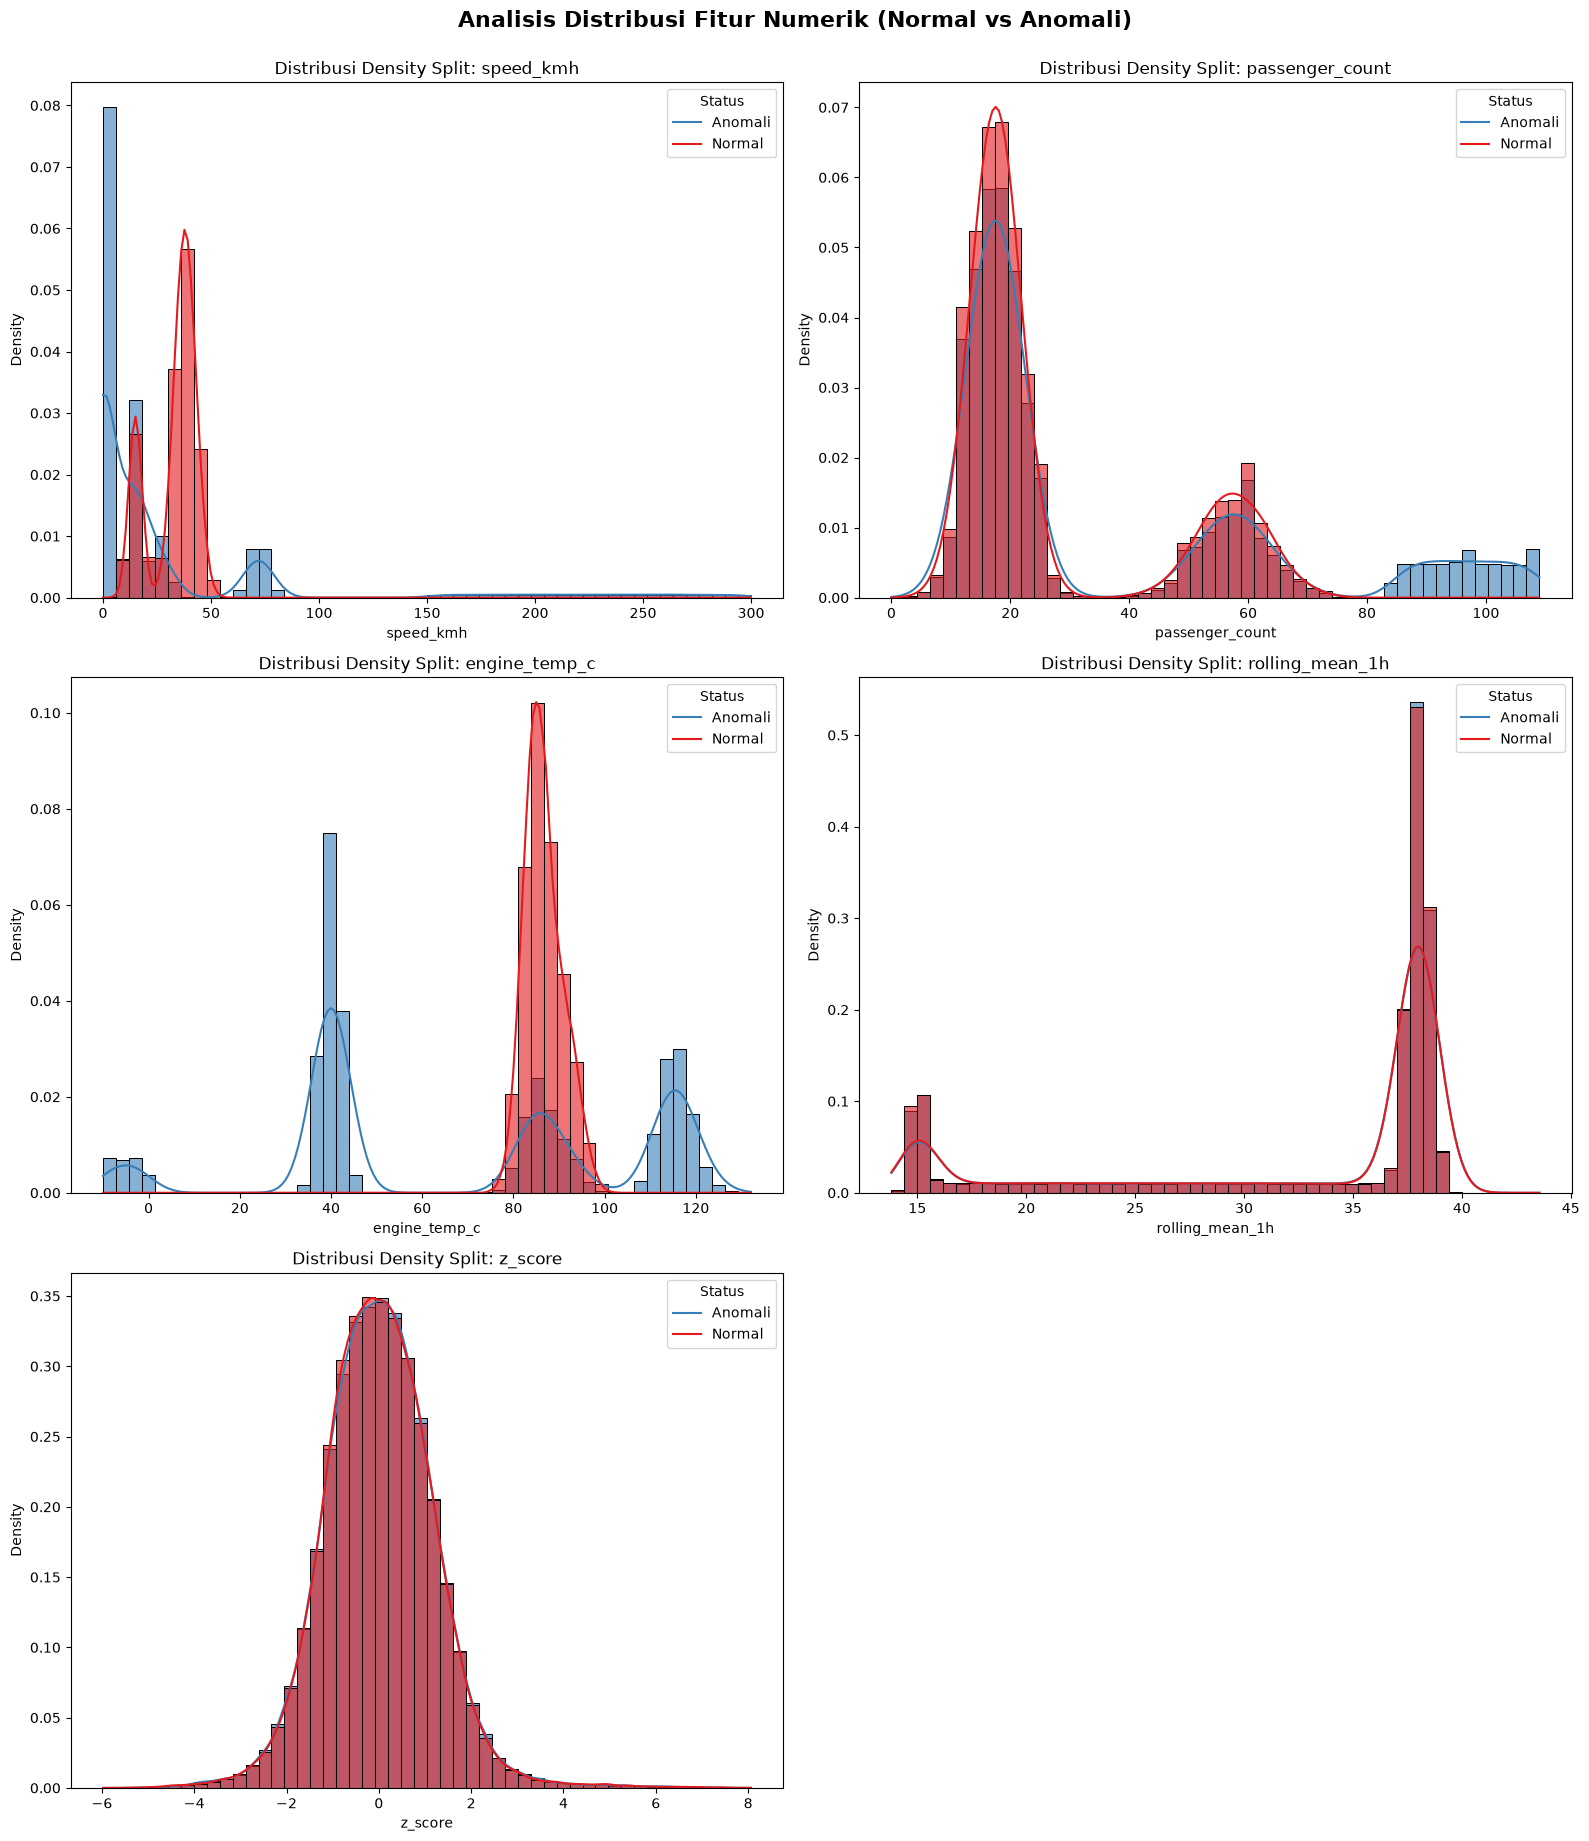

In [18]:
df_normal_sample = df[df['is_anomaly'] == 0].sample(n=100000, random_state=42)
df_anomaly = df[df['is_anomaly'] == 1]
df_eda_numeric = pd.concat([df_normal_sample, df_anomaly])

features = ['speed_kmh', 'passenger_count', 'engine_temp_c', 'rolling_mean_1h', 'z_score']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df_eda_numeric, x=col, hue='is_anomaly', kde=True, 
                 stat="density", common_norm=False, bins=50, ax=axes[i], palette='Set1', alpha=0.6)
    axes[i].set_title(f'Distribusi Density Split: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(title='Status', labels=['Anomali', 'Normal'])

# Hapus subplot ke-6 yang kosong
fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Analisis Distribusi Fitur Numerik (Normal vs Anomali)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

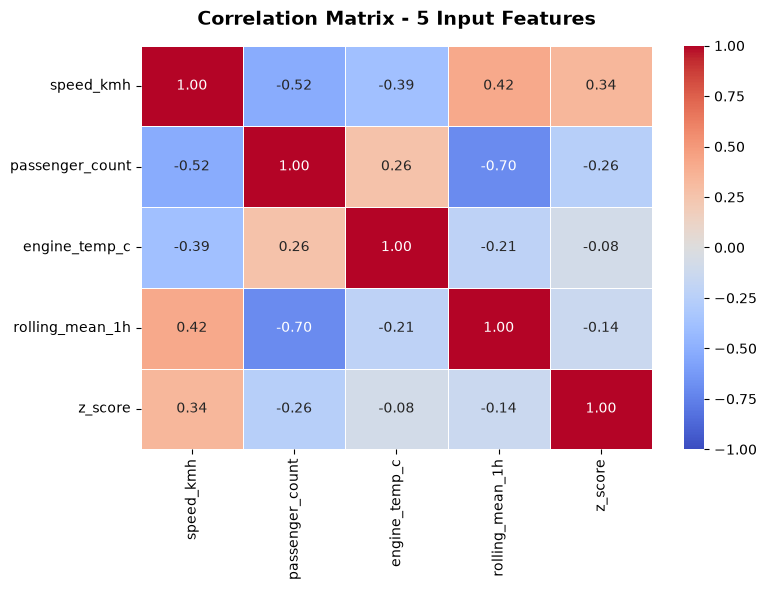

In [19]:
plt.figure(figsize=(8, 6))

# Menghitung korelasi hanya pada 5 fitur utama
corr_matrix = df[features].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix - 5 Input Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

C:\Users\Wahfi\AppData\Local\Temp\ipykernel_19728\2629526590.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='anomaly_type', y='speed_kmh', ax=axes[0], order=anomaly_order, palette='Set2')
C:\Users\Wahfi\AppData\Local\Temp\ipykernel_19728\2629526590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='anomaly_type', y='engine_temp_c', ax=axes[1], order=anomaly_order, palette='Set2')
C:\Users\Wahfi\AppData\Local\Temp\ipykernel_19728\2629526590.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='anomaly_

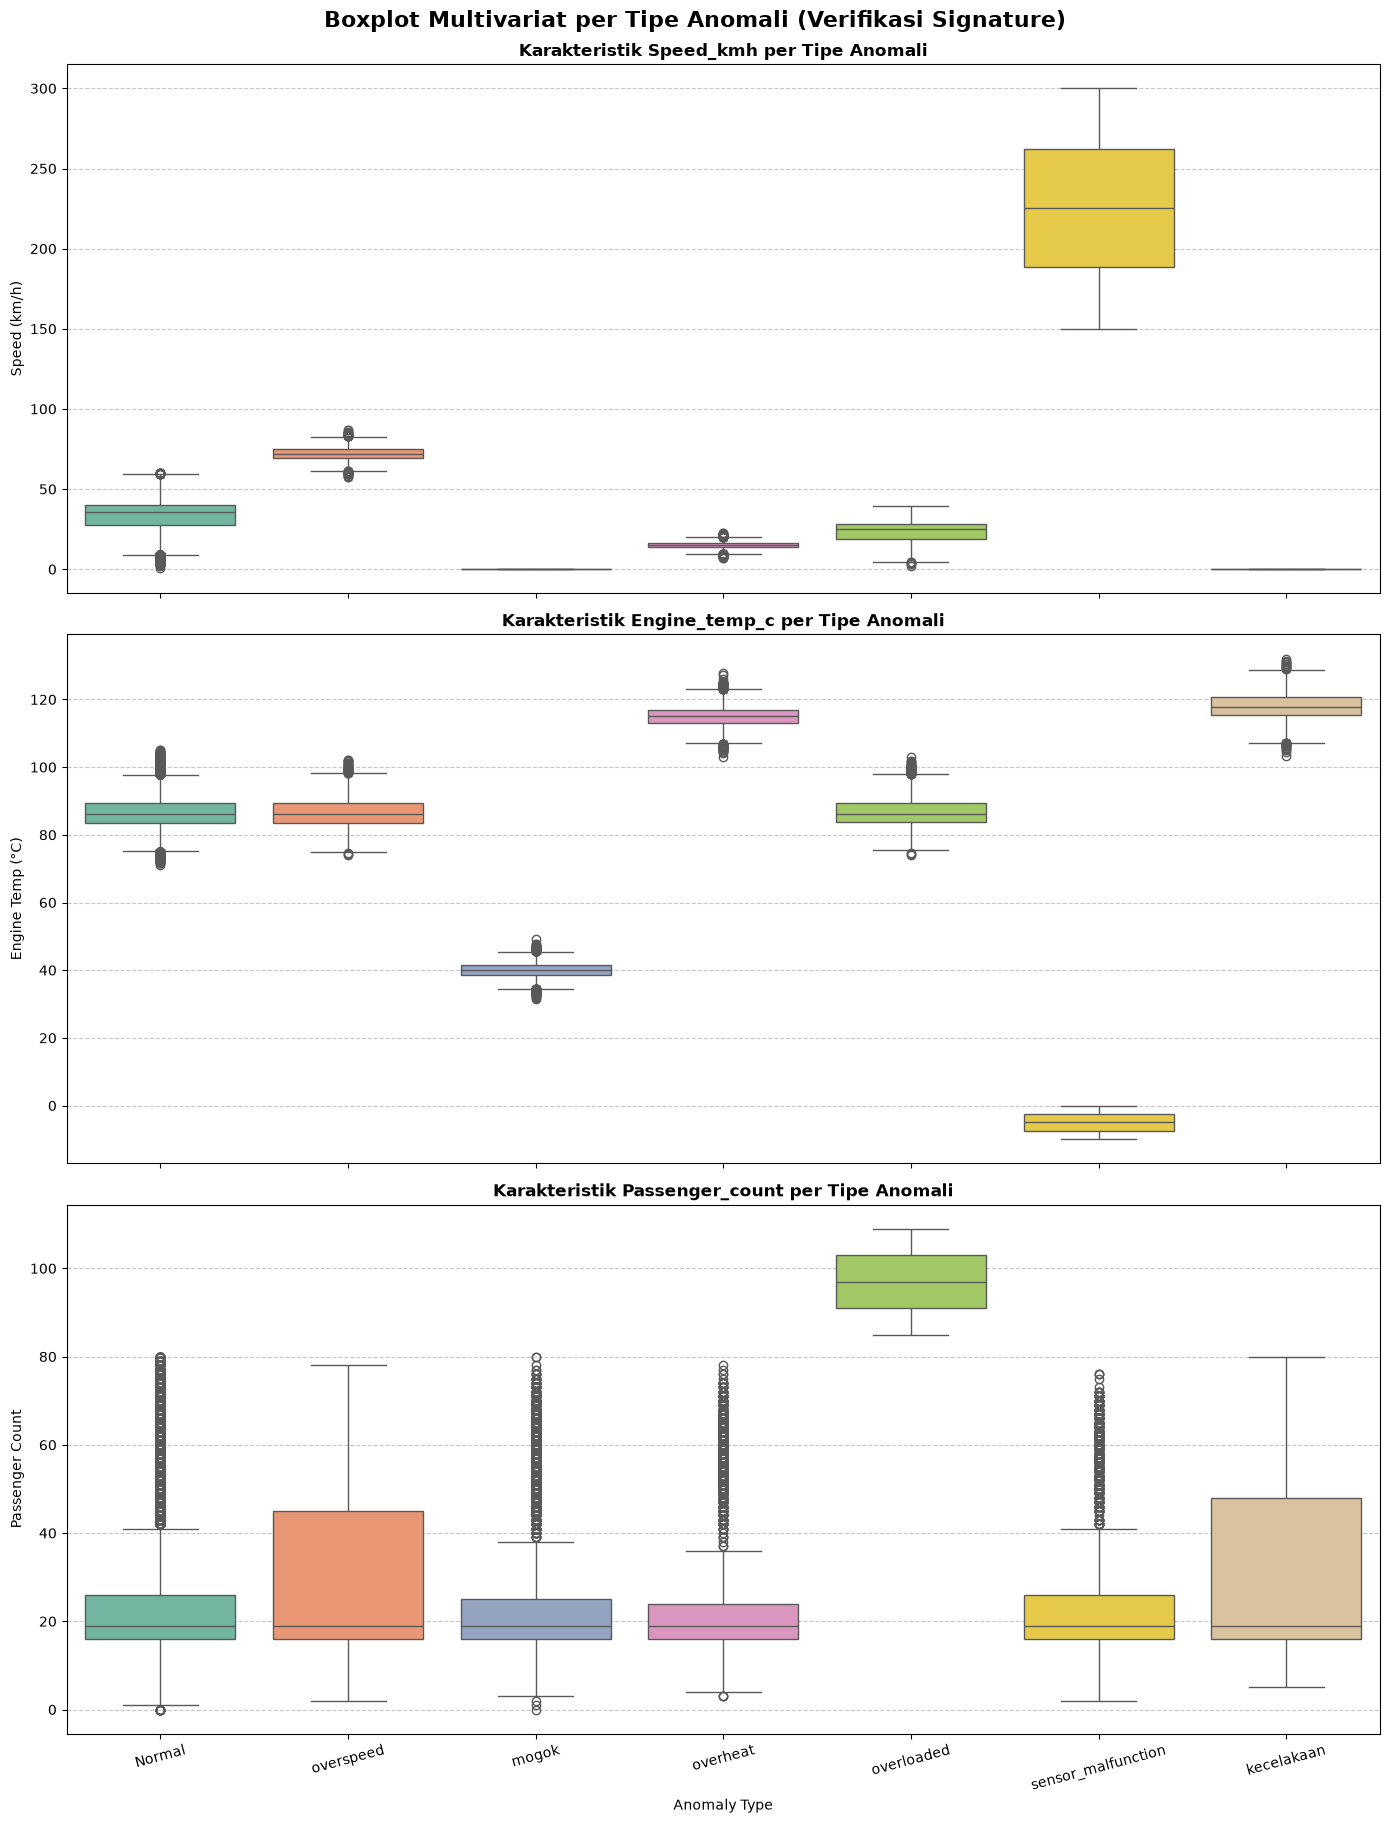

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Urutan agar plot rapi
anomaly_order = ['Normal', 'overspeed', 'mogok', 'overheat', 'overloaded', 'sensor_malfunction', 'kecelakaan']

# 1. Boxplot Speed
sns.boxplot(data=df, x='anomaly_type', y='speed_kmh', ax=axes[0], order=anomaly_order, palette='Set2')
axes[0].set_title('Karakteristik Speed_kmh per Tipe Anomali', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Speed (km/h)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Boxplot Engine Temperature
sns.boxplot(data=df, x='anomaly_type', y='engine_temp_c', ax=axes[1], order=anomaly_order, palette='Set2')
axes[1].set_title('Karakteristik Engine_temp_c per Tipe Anomali', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Engine Temp (°C)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Boxplot Passenger Count
sns.boxplot(data=df, x='anomaly_type', y='passenger_count', ax=axes[2], order=anomaly_order, palette='Set2')
axes[2].set_title('Karakteristik Passenger_count per Tipe Anomali', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Passenger Count')
axes[2].set_xlabel('Anomaly Type')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=15)
plt.tight_layout()
plt.suptitle('Boxplot Multivariat per Tipe Anomali (Verifikasi Signature)', y=1.01, fontsize=16, fontweight='bold')
plt.show()

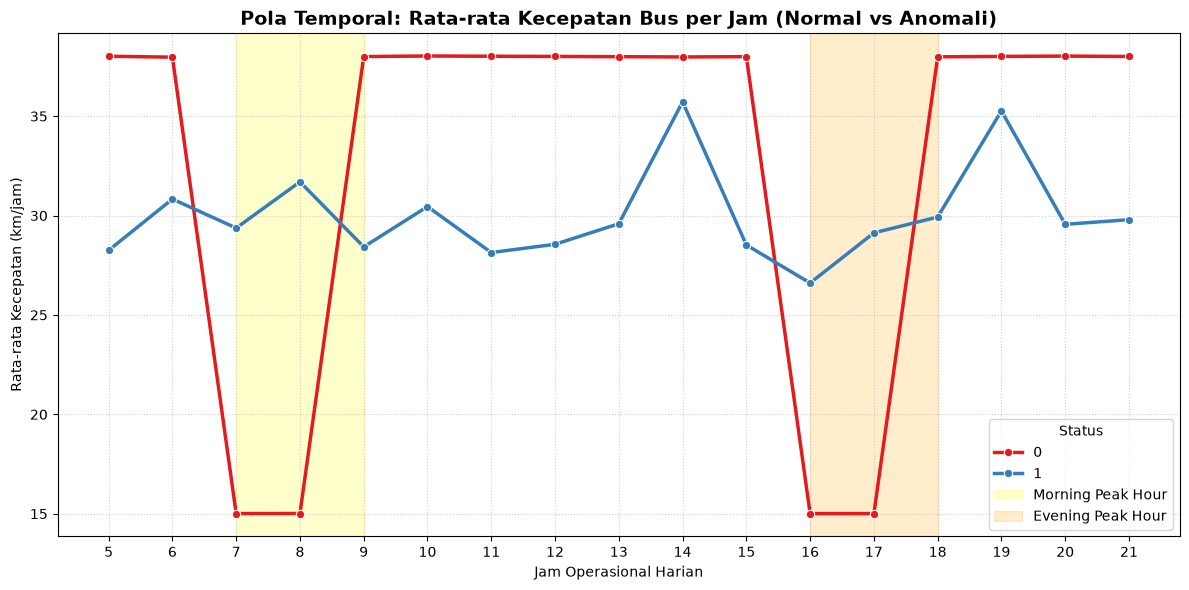

In [21]:
plt.figure(figsize=(12, 6))

# Hitung rata-rata kecepatan tiap jam operasional, dipisah berdasarkan Normal vs Anomali
hourly_speed = df.groupby(['hour', 'is_anomaly'])['speed_kmh'].mean().reset_index()

# Plot Linechart
sns.lineplot(data=hourly_speed, x='hour', y='speed_kmh', hue='is_anomaly', 
             marker='o', palette='Set1', linewidth=2.5)

# Highlight Area Peak Hour di Grafik
plt.axvspan(7, 9, color='yellow', alpha=0.2, label='Morning Peak Hour')
plt.axvspan(16, 18, color='orange', alpha=0.2, label='Evening Peak Hour')

plt.title('Pola Temporal: Rata-rata Kecepatan Bus per Jam (Normal vs Anomali)', fontsize=14, fontweight='bold')
plt.xlabel('Jam Operasional Harian')
plt.ylabel('Rata-rata Kecepatan (km/jam)')
plt.xticks(range(OP_START, OP_END))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Status')

plt.tight_layout()
plt.show()

C:\Users\Wahfi\AppData\Local\Temp\ipykernel_19728\3376791261.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='anomaly_type', ax=axes[0], order=df['anomaly_type'].value_counts().index, palette='viridis')
C:\Users\Wahfi\AppData\Local\Temp\ipykernel_19728\3376791261.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='severity', ax=axes[1], order=['Low', 'Medium', 'High'], palette='magma')


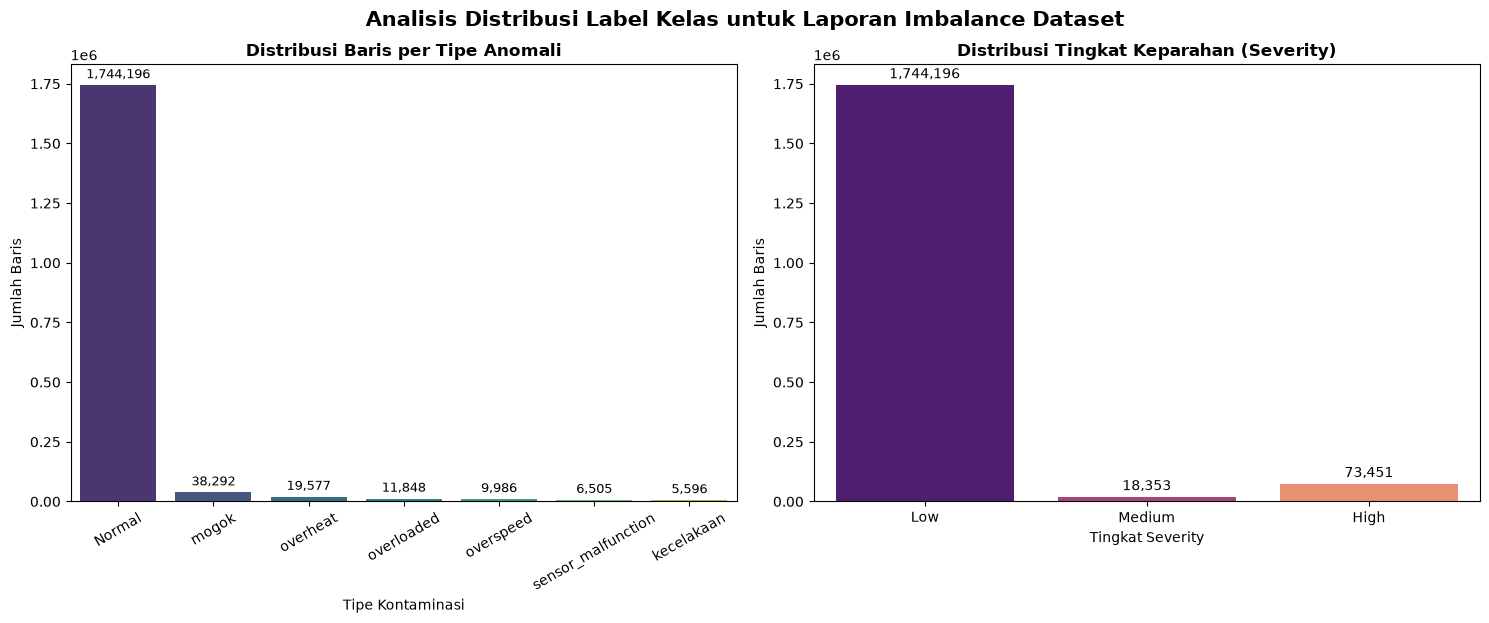

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Plot Anomaly Type
sns.countplot(data=df, x='anomaly_type', ax=axes[0], order=df['anomaly_type'].value_counts().index, palette='viridis')
axes[0].set_title('Distribusi Baris per Tipe Anomali', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipe Kontaminasi')
axes[0].set_ylabel('Jumlah Baris')
axes[0].tick_params(axis='x', rotation=30)
# Tambahkan label teks angka di atas bar
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')

# 2. Bar Plot Severity
sns.countplot(data=df, x='severity', ax=axes[1], order=['Low', 'Medium', 'High'], palette='magma')
axes[1].set_title('Distribusi Tingkat Keparahan (Severity)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tingkat Severity')
axes[1].set_ylabel('Jumlah Baris')
# Tambahkan label teks angka di atas bar
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.suptitle('Analisis Distribusi Label Kelas untuk Laporan Imbalance Dataset', y=1.03, fontsize=15, fontweight='bold')
plt.show()